Análise Exploratória — Consumo de Combustível e Orçamento de Esquadrão
(dados 100% sintéticos — ver dicionario_de_dados.md)

Este script é a versão .py do notebook 01_analise.ipynb (mesmo conteúdo,
célula por célula). Rode em Google Colab, Jupyter local ou como script.

# Análise de Consumo de Combustível e Orçamento — Esquadrão Naval (fictício)

**Pergunta de negócio:** quais embarcações e categorias operacionais mais
pressionam o orçamento de combustível, e como o consumo varia ao longo do
ano? O objetivo é simular o tipo de análise usada para embasar decisões de
alocação de cota e verba entre unidades subordinadas — tarefa que já
desempenhei na rotina real de logística naval, aqui replicada com dados
fictícios.

**Fonte dos dados:** sintéticos, gerados por `dados/gerar_dados_sinteticos.py`
com seed fixa (42) para reprodutibilidade. Não representam nenhum dado real.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6), 'figure.dpi': 150, 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.labelsize': 11,
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']

BASE = Path(__file__).parent.parent
IMG_DIR = BASE / "imagens"
IMG_DIR.mkdir(exist_ok=True)

## 1. Carregar e unir as tabelas (equivalente ao JOIN em SQL)

In [2]:
embarcacoes = pd.read_csv(BASE / "dados/brutos/dim_embarcacoes.csv")
combustivel = pd.read_csv(BASE / "dados/brutos/fato_consumo_combustivel.csv", parse_dates=["competencia"])
orcamento = pd.read_csv(BASE / "dados/brutos/fato_orcamento.csv", parse_dates=["competencia"])

combustivel = combustivel.merge(embarcacoes, on="vessel_id", how="left")
print(combustivel.shape, orcamento.shape)
combustivel.head()

(144, 9) (576, 6)


   record_id vessel_id  ... vessel_class capacidade_tanque_litros
0          1       V01  ...      Fragata                   850000
1          2       V01  ...      Fragata                   850000
2          3       V01  ...      Fragata                   850000
3          4       V01  ...      Fragata                   850000
4          5       V01  ...      Fragata                   850000

[5 rows x 9 columns]

## 2. Visão geral (equivalente a funções agregadas em SQL)

In [3]:
resumo = combustivel.agg(
    total_litros=("litros_consumidos", "sum"),
    media_mensal=("litros_consumidos", "mean"),
    maximo=("litros_consumidos", "max"),
    minimo=("litros_consumidos", "min"),
)
print(resumo)

              litros_consumidos
total_litros       4.737378e+06
media_mensal       3.289846e+04
maximo             6.439300e+04
minimo             1.601300e+04


## 3. Consumo total por embarcação, ordenado (equivalente a GROUP BY + ORDER BY)

In [4]:
consumo_por_embarcacao = (
    combustivel.groupby(["vessel_name", "vessel_class"])["litros_consumidos"]
    .sum()
    .reset_index()
    .sort_values("litros_consumidos", ascending=True)
)
consumo_por_embarcacao

                 vessel_name vessel_class  litros_consumidos
0        NE Angra (fictício)      Corveta             559722
1       NE Búzios (fictício)      Corveta             561611
4       NE Maricá (fictício)      Corveta             603397
5       NE Paraty (fictício)      Fragata             983425
2    NE Cabo Frio (fictício)      Fragata            1004493
3  NE Ilha Grande (fictício)      Fragata            1024730

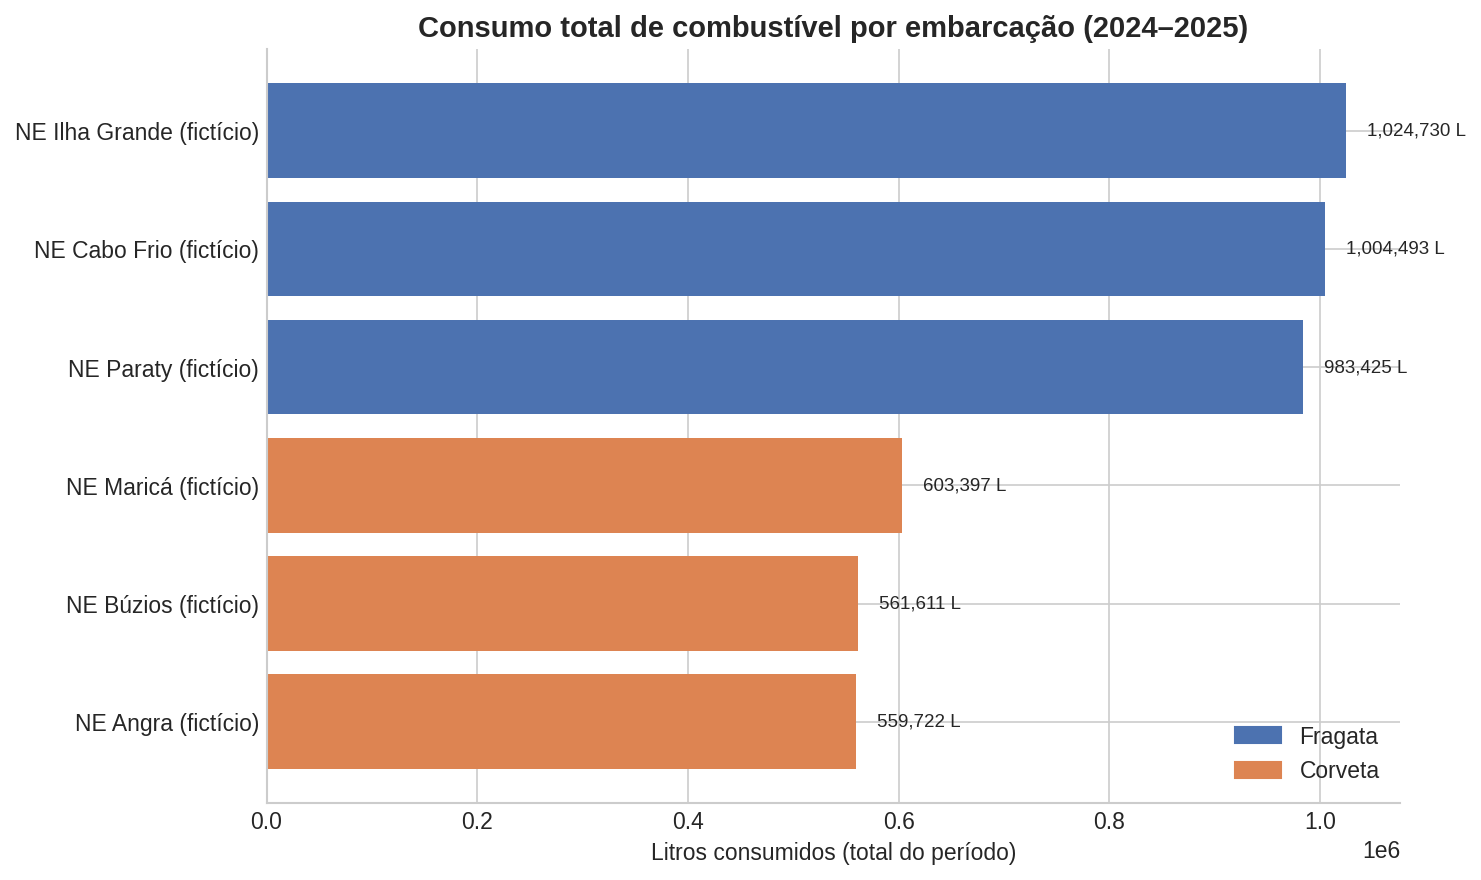

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
cores = [PALETTE[0] if c == "Fragata" else PALETTE[1] for c in consumo_por_embarcacao["vessel_class"]]
bars = ax.barh(consumo_por_embarcacao["vessel_name"], consumo_por_embarcacao["litros_consumidos"], color=cores)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 20000, bar.get_y() + bar.get_height()/2, f"{w:,.0f} L", va="center", fontsize=9)
ax.set_title("Consumo total de combustível por embarcação (2024–2025)")
ax.set_xlabel("Litros consumidos (total do período)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=PALETTE[0], label='Fragata'), Patch(color=PALETTE[1], label='Corveta')], loc='lower right')
plt.tight_layout()
plt.savefig(IMG_DIR / "01_consumo_por_embarcacao.png", dpi=150, bbox_inches="tight")
plt.close()

## 4. Sazonalidade: consumo mensal agregado da frota (série temporal)

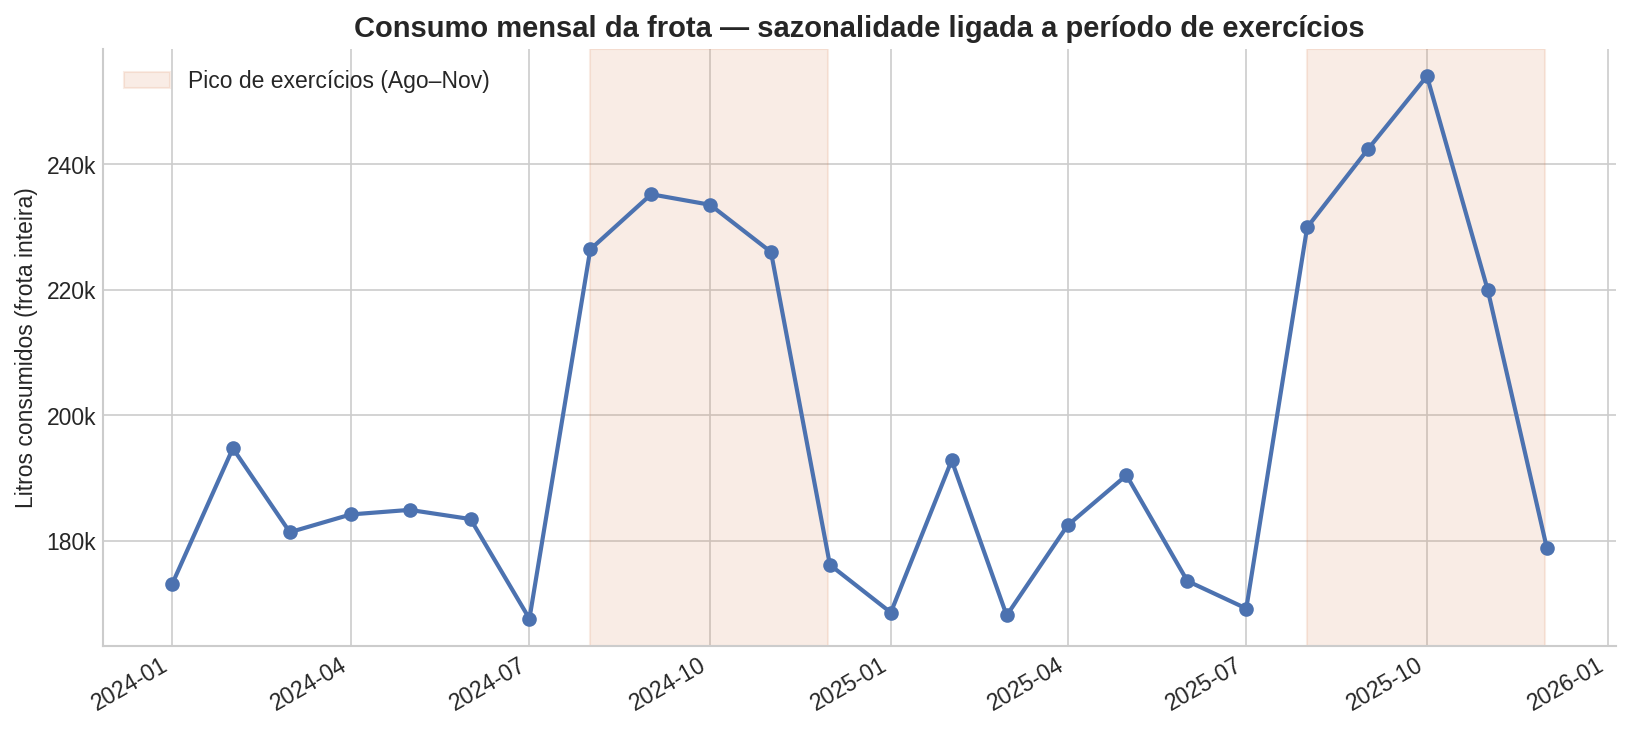

In [6]:
consumo_mensal = combustivel.groupby("competencia")["litros_consumidos"].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(consumo_mensal["competencia"], consumo_mensal["litros_consumidos"], marker="o", color=PALETTE[0], linewidth=2)
ax.axvspan(pd.Timestamp("2024-08-01"), pd.Timestamp("2024-11-30"), color=PALETTE[1], alpha=0.15, label="Pico de exercícios (Ago–Nov)")
ax.axvspan(pd.Timestamp("2025-08-01"), pd.Timestamp("2025-11-30"), color=PALETTE[1], alpha=0.15)
ax.set_title("Consumo mensal da frota — sazonalidade ligada a período de exercícios")
ax.set_ylabel("Litros consumidos (frota inteira)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x/1000:.0f}k"))
ax.legend(loc="upper left")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(IMG_DIR / "02_sazonalidade_mensal.png", dpi=150, bbox_inches="tight")
plt.close()

## 5. Estouro de cota por categoria operacional (equivalente a CASE WHEN)

In [7]:
combustivel["variacao_pct"] = 100 * (combustivel["litros_consumidos"] - combustivel["litros_cota_alocada"]) / combustivel["litros_cota_alocada"]
combustivel["status_cota"] = np.where(combustivel["variacao_pct"] > 0, "Estourou a cota", "Dentro da cota")

estouro_por_categoria = (
    combustivel[combustivel["status_cota"] == "Estourou a cota"]
    .groupby("categoria_operacional")
    .size()
    .reset_index(name="qtd_meses_com_estouro")
    .sort_values("qtd_meses_com_estouro", ascending=False)
)
estouro_por_categoria

  categoria_operacional  qtd_meses_com_estouro
1              Operação                     22
2           Treinamento                     10
0            Manutenção                      9

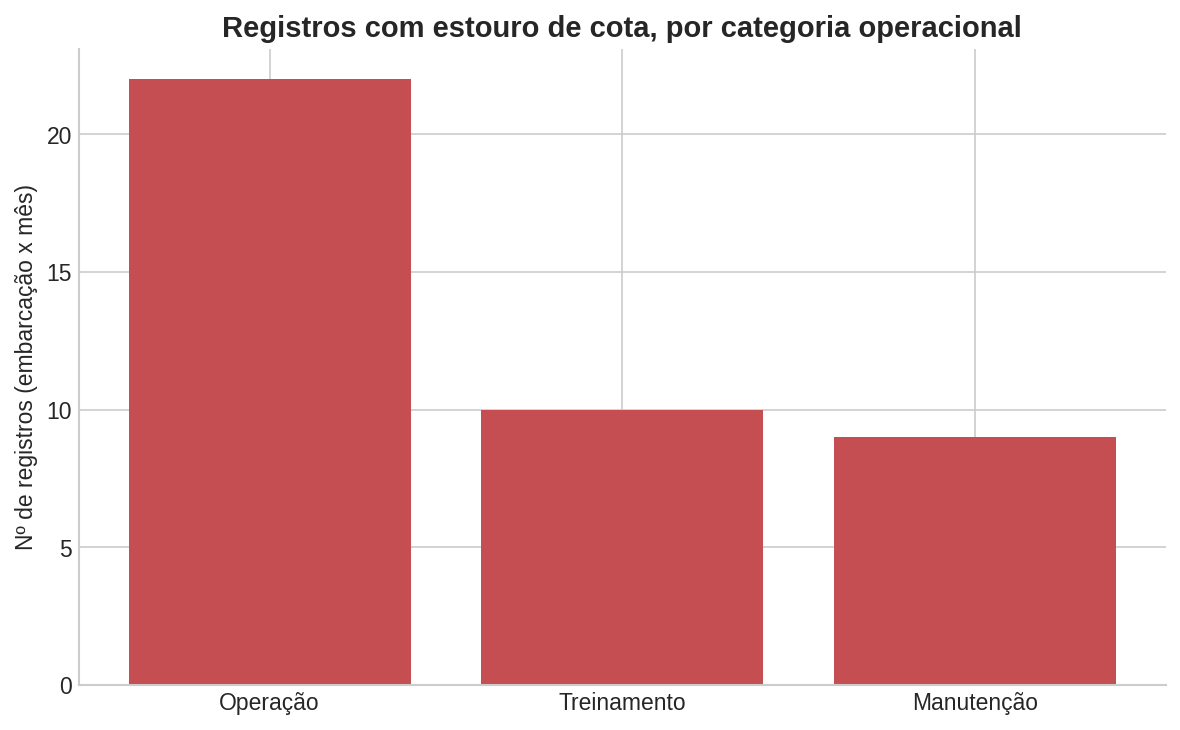

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(estouro_por_categoria["categoria_operacional"], estouro_por_categoria["qtd_meses_com_estouro"], color=PALETTE[3])
ax.set_title("Registros com estouro de cota, por categoria operacional")
ax.set_ylabel("Nº de registros (embarcação x mês)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(IMG_DIR / "03_estouro_por_categoria.png", dpi=150, bbox_inches="tight")
plt.close()

## 6. Orçamento: alocado vs. gasto por embarcação (equivalente ao CTE em SQL)

In [9]:
orcamento_full = orcamento.merge(embarcacoes[["vessel_id", "vessel_name"]], on="vessel_id")
resumo_orcamento = (
    orcamento_full.groupby("vessel_name")[["orcamento_alocado_brl", "orcamento_gasto_brl"]]
    .sum()
    .reset_index()
)
resumo_orcamento["estouro_pct"] = 100 * (resumo_orcamento["orcamento_gasto_brl"] - resumo_orcamento["orcamento_alocado_brl"]) / resumo_orcamento["orcamento_alocado_brl"]
resumo_orcamento = resumo_orcamento.sort_values("estouro_pct", ascending=False)
resumo_orcamento

                 vessel_name  ...  estouro_pct
0        NE Angra (fictício)  ...     1.717047
1       NE Búzios (fictício)  ...     1.302351
5       NE Paraty (fictício)  ...     1.091305
3  NE Ilha Grande (fictício)  ...     1.024340
2    NE Cabo Frio (fictício)  ...     0.680128
4       NE Maricá (fictício)  ...    -0.429811

[6 rows x 4 columns]

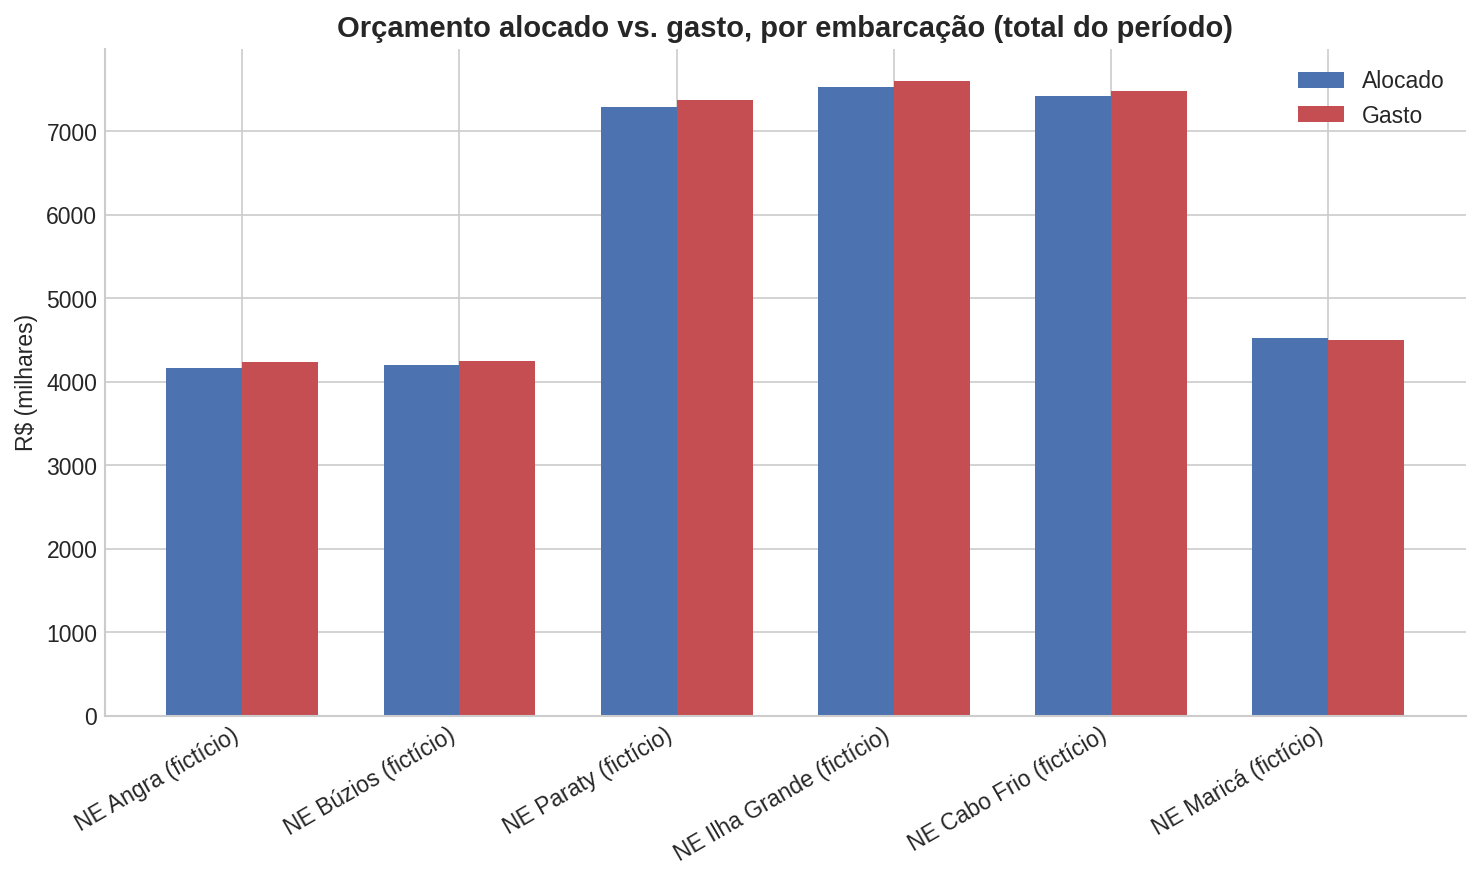

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(resumo_orcamento))
largura = 0.35
ax.bar(x - largura/2, resumo_orcamento["orcamento_alocado_brl"]/1000, largura, label="Alocado", color=PALETTE[0])
ax.bar(x + largura/2, resumo_orcamento["orcamento_gasto_brl"]/1000, largura, label="Gasto", color=PALETTE[3])
ax.set_xticks(x)
ax.set_xticklabels(resumo_orcamento["vessel_name"], rotation=30, ha="right")
ax.set_ylabel("R$ (milhares)")
ax.set_title("Orçamento alocado vs. gasto, por embarcação (total do período)")
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(IMG_DIR / "04_orcamento_alocado_vs_gasto.png", dpi=150, bbox_inches="tight")
plt.close()

## 7. Principais achados

1. Frota consome mais combustível entre agosto e novembro (período de
   exercícios), com picos ~25% acima da média — relevante para
   planejamento antecipado de cota nesse trimestre.
2. A categoria "Operação" concentra a maior parte dos registros de estouro
   de cota, sugerindo que o modelo de alocação atual pode estar
   subdimensionado para meses operacionais intensos.
3. Todas as embarcações fecharam o período com gasto de combustível acima
   do orçamento alocado (estouro entre ~0,7% e ~1,7%), com fragatas
   concentrando o maior valor absoluto de desvio.

*(Achados baseados em dados fictícios — servem para demonstrar o raciocínio
analítico, não representam a situação real de nenhuma unidade.)*

print("Notebook executado com sucesso. Gráficos salvos em /imagens.")